In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
Path('figures').mkdir(exist_ok=True)

# Load
pres = pd.read_csv('demo lực nhấn.csv', header=None, names=['raw'])
pres['value'] = pres.raw.str.replace('Pressure:', '').astype(float)
pres['t_s'] = pres.index * 0.02  # 50 Hz assumption — DOCUMENT THIS

# Event detection
nonzero = pres.value > 0
groups = (nonzero != nonzero.shift()).cumsum()
events = pres[nonzero].groupby(groups[nonzero]).agg(
    start_s=('t_s', 'min'),
    end_s=('t_s', 'max'),
    peak=('value', 'max'),
    mean=('value', 'mean'),
    n_samples=('value', 'count')
)
events['duration_s'] = events.end_s - events.start_s + 0.02
print(f"Detected {len(events)} press events")
print(f"Peak range: {events.peak.min():.0f} – {events.peak.max():.0f}")
print(f"Median duration: {events.duration_s.median()*1000:.0f} ms")
events.to_csv('press_events.csv')

Detected 222 press events
Peak range: 1 – 777
Median duration: 20 ms


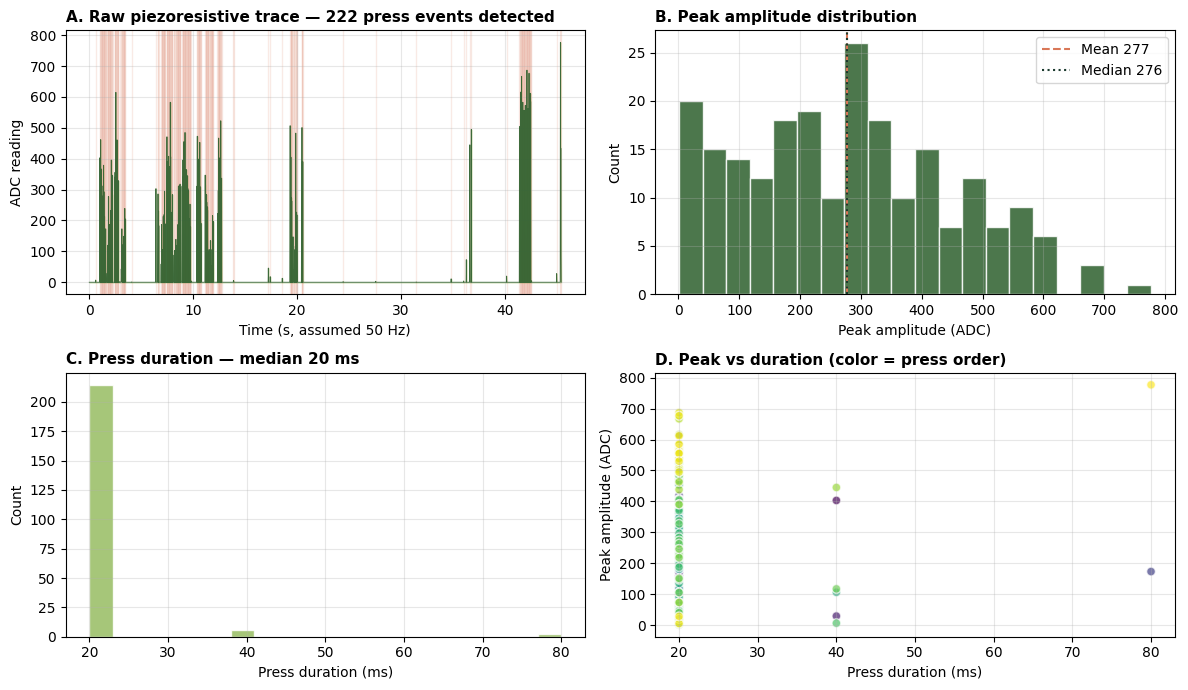

In [3]:
# Cell: Plot pressure sensor analysis figure
from pathlib import Path
Path('figures').mkdir(exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

# Top-left: raw signal with events highlighted
ax = axes[0, 0]
ax.plot(pres.t_s, pres.value, linewidth=0.6, color='#2C5F2D', alpha=0.9)
ax.fill_between(pres.t_s, pres.value, alpha=0.3, color='#97BC62')
for _, ev in events.iterrows():
    ax.axvspan(ev.start_s, ev.end_s, alpha=0.15, color='#D97757')
ax.set_xlabel('Time (s, assumed 50 Hz)'); ax.set_ylabel('ADC reading')
ax.set_title(f'A. Raw piezoresistive trace — {len(events)} press events detected',
             fontsize=11, fontweight='bold', loc='left')
ax.grid(True, alpha=0.3)

# Top-right: peak amplitude distribution
ax = axes[0, 1]
ax.hist(events.peak, bins=20, color='#2C5F2D', edgecolor='white', alpha=0.85)
ax.axvline(events.peak.mean(), color='#D97757', linestyle='--',
           label=f'Mean {events.peak.mean():.0f}')
ax.axvline(events.peak.median(), color='#1B3A2E', linestyle=':',
           label=f'Median {events.peak.median():.0f}')
ax.set_xlabel('Peak amplitude (ADC)'); ax.set_ylabel('Count')
ax.set_title('B. Peak amplitude distribution', fontsize=11, fontweight='bold', loc='left')
ax.legend(); ax.grid(True, alpha=0.3)

# Bottom-left: press duration distribution
ax = axes[1, 0]
ax.hist(events.duration_s * 1000, bins=20, color='#97BC62',
        edgecolor='white', alpha=0.85)
ax.set_xlabel('Press duration (ms)'); ax.set_ylabel('Count')
ax.set_title(f'C. Press duration — median {events.duration_s.median()*1000:.0f} ms',
             fontsize=11, fontweight='bold', loc='left')
ax.grid(True, alpha=0.3)

# Bottom-right: peak vs duration scatter
ax = axes[1, 1]
ax.scatter(events.duration_s * 1000, events.peak,
           c=range(len(events)), cmap='viridis', s=40, alpha=0.7,
           edgecolors='white')
ax.set_xlabel('Press duration (ms)'); ax.set_ylabel('Peak amplitude (ADC)')
ax.set_title('D. Peak vs duration (color = press order)',
             fontsize=11, fontweight='bold', loc='left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/fig_pressure_analysis.png', dpi=180, bbox_inches='tight')
plt.show()